In [88]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pickle

from MDAnalysis.analysis.rdf import InterRDF
import MDAnalysis as mda
from MDAnalysis.analysis import rdf

In [ ]:
# Old color mapping for sizes
size_colors = {"small": "#e74c3c", "medium": "#27ae60", "large": "#f39c12"}
marker_styles = {"grace": "o", "mace": "s", "experiment": "X"}

# Color mapping for model types
model_type_colors = {
    "GRACE_1L": "#e74c3c",  # red for GRACE 1L
    "GRACE_2L": "#f39c12",  # green for GRACE 2L
    "MACE": "#27ae60",      # orange for MACE
    "UMA": "#9b59b6",
}

# Alpha mapping for sizes (small = fully visible, large = 50%)
size_alpha = {"S": 1.0, "M": 0.75, "L": 0.5}

markers = {
    "GRACE (2L-S)": "o",
    "GRACE (2L-M)": "p",
    "GRACE (2L-L)": "8",
    "Experiment": "X",
    "MACE-OFF23(S)": "v",
    "MACE-OFF23(M)": "^",
    "MACE-OFF23(L)": ">",
    "UMA (S)": "*",
}

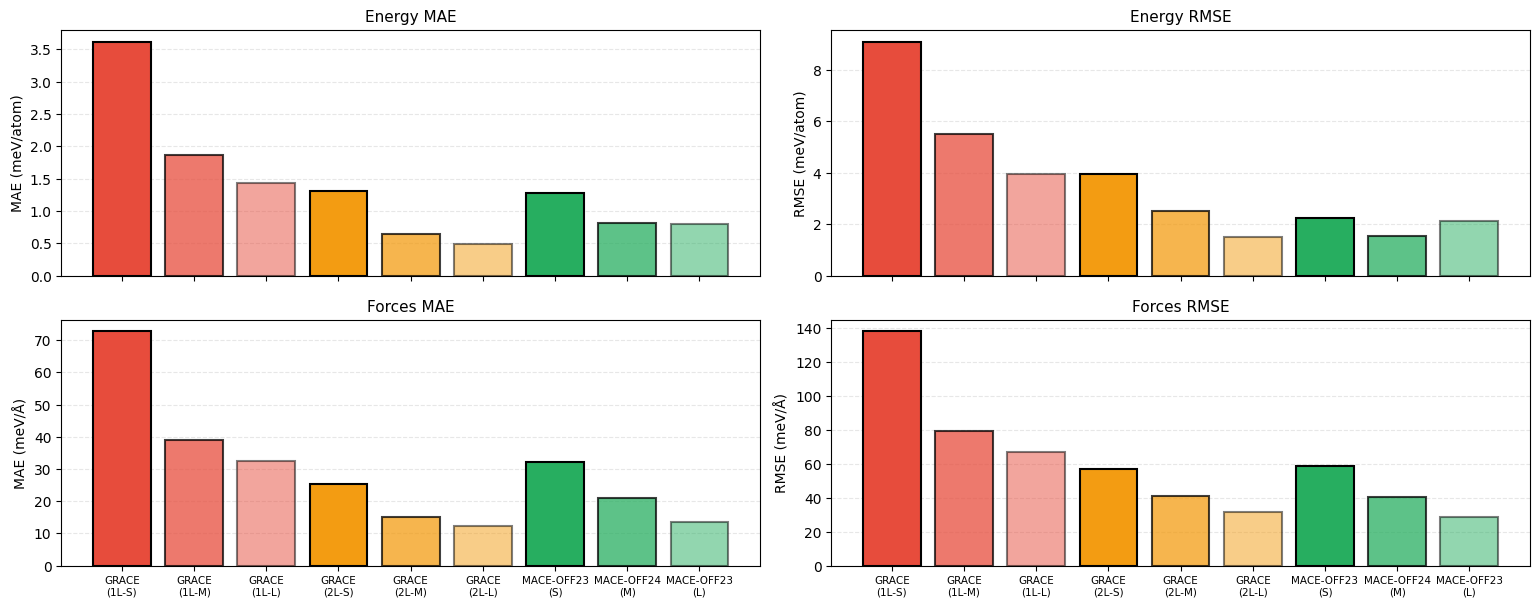

In [149]:
##### Final Plots for Energies and Forces #####

# Load data
# There are two possible files, energies_per_atom -> structures seen by GRACE and MACE, energies_per_atom_ood -> structure NOT seen by GRACE
df = pd.read_csv("energies/energies_per_atom_ood.csv")

df["model"] = df["model"].str.upper()
df["size"] = df["size"].replace("2l_small", "(2L-S)")
df["size"] = df["size"].replace("2l_medium", "(2L-M)")
df["size"] = df["size"].replace("2l_large", "(2L-L)")
df["size"] = df["size"].replace("1l_small", "(1L-S)")
df["size"] = df["size"].replace("1l_medium", "(1L-M)")
df["size"] = df["size"].replace("1l_large", "(1L-L)")

# Extract layers and model_size from the reformatted size column
df["layers"] = df["size"].str.extract(r"(\d+L)")[0].str.lower()
df["model_size"] = df["size"]

# Include both 1-layer and 2-layer models (plus MACE)
df = df[(df["layers"].isin(["1l", "2l"])) | (df["model"] == "MACE")].copy()


# Sort order: GRACE 1L (S, M, L), then GRACE 2L (S, M, L), then MACE (S, M, L)
def get_sort_key(row):
    # Layer/model group order: GRACE 1L first (0), GRACE 2L second (1), MACE third (2)
    if row["model"] == "GRACE" and row["layers"] == "1l":
        group_order = 0
    elif row["model"] == "GRACE" and row["layers"] == "2l":
        group_order = 1
    elif row["model"] == "MACE":
        group_order = 2
    else:
        group_order = 3
    
    # Size order within each group: small first, then medium, then large
    size_order = {"(1L-S)": 0, "(2L-S)": 0, "(1L-M)": 1, "(2L-M)": 1, "(1L-L)": 2, "(2L-L)": 2}
    size_val = size_order.get(row["model_size"], 3)
    
    return (group_order, size_val)


df["sort_keys"] = df.apply(get_sort_key, axis=1)
df = df.sort_values("sort_keys").reset_index(drop=True)
df = df.drop("sort_keys", axis=1)


# Create x-axis labels: include size and layer info
def create_label(row):
    if row["model"] == "MACE":
        size_str = row["model_size"].replace("2L-", "").replace("1L-", "")
        if size_str == "(S)":
            return f"MACE-OFF23\n{size_str}"
        elif size_str == "(M)":
            return f"MACE-OFF24\n{size_str}"
        elif size_str == "(L)":
            return f"MACE-OFF23\n{size_str}"
        else:
            return f"{row['model']}\n{size_str}"
    else:
        return f"{row['model']}\n{row['model_size']}"


df["x_label"] = df.apply(create_label, axis=1)

# Separate MACE rows for reference lines
df_mace = df[df["model"] == "MACE"].copy()
df_mace["size_cat"] = df_mace["model_size"].apply(lambda s: "S" if "S" in s else ("M" if "M" in s else "L"))

# Create 2x2 subplot with shared x-axis
fig, axes = plt.subplots(2, 2, figsize=(15.5, 6.5), sharex=True)
axes = axes.flatten()

# Metrics to plot: (column_name, title, ylabel, unit)
metrics = [
    ("energy_mae_meV", "Energy MAE", "MAE (meV/atom)"),
    ("energy_rmse_meV", "Energy RMSE", "RMSE (meV/atom)"),
    ("forces_mae_meV_per_A", "Forces MAE", "MAE (meV/Å)"),
    ("forces_rmse_meV_per_A", "Forces RMSE", "RMSE (meV/Å)"),
]

# Helper function to get model type
def get_model_type(row):
    if row["model"] == "MACE":
        return "MACE"
    elif row["layers"] == "1l":
        return "GRACE_1L"
    else:
        return "GRACE_2L"

# Helper function to get size category
def get_size_category(model_size):
    if "S" in model_size:
        return "S"
    elif "M" in model_size:
        return "M"
    else:
        return "L"

# Plot each metric
for idx, (metric, title, ylabel) in enumerate(metrics):
    ax = axes[idx]

    # Get unique x positions
    x_positions = np.arange(len(df))

    # Create bars with colors based on model type and alpha based on size
    for i, (_, row) in enumerate(df.iterrows()):
        model_type = get_model_type(row)
        size_cat = get_size_category(row["model_size"])
        color = model_type_colors[model_type]
        alpha = size_alpha[size_cat]
        hatch = "///" if row["model"] == "MACE" else ""
        
        bar = ax.bar(
            x_positions[i],
            row[metric],
            color=color,
            alpha=alpha,
            edgecolor="black",
            linewidth=1.5,
            # hatch=hatch,
        )

    # Add horizontal reference lines for each MACE model
    # for _, mace_row in df_mace.iterrows():
    #     size_cat = mace_row["size_cat"]
    #     val = mace_row[metric]
    #     ax.axhline(
    #         y=val,
    #         color=model_type_colors["MACE"],
    #         alpha=size_alpha[size_cat],
    #         linestyle="--",
    #         linewidth=1.2,
    #         zorder=0,
    #     )

    # Customize plot
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(df["x_label"], fontsize=7.5, rotation=0)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)

from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

size_tuple_1l = (
    Patch(facecolor=model_type_colors["GRACE_1L"], edgecolor="black", alpha=1.0),
    Patch(facecolor=model_type_colors["GRACE_1L"], edgecolor="black", alpha=0.75),
    Patch(facecolor=model_type_colors["GRACE_1L"], edgecolor="black", alpha=0.5),
)

size_tuple_2l = (
    Patch(facecolor=model_type_colors["GRACE_2L"], edgecolor="black", alpha=1.0),
    Patch(facecolor=model_type_colors["GRACE_2L"], edgecolor="black", alpha=0.75),
    Patch(facecolor=model_type_colors["GRACE_2L"], edgecolor="black", alpha=0.5),
)

size_tuple_mace = (
    Patch(facecolor=model_type_colors["MACE"], edgecolor="black", alpha=1.0),
    Patch(facecolor=model_type_colors["MACE"], edgecolor="black", alpha=0.75),
    Patch(facecolor=model_type_colors["MACE"], edgecolor="black", alpha=0.5),
)

legend_elements = [
    size_tuple_1l,
    size_tuple_2l,
    size_tuple_mace,

]

# fig.legend(
#     handles=legend_elements,
#     labels=["GRACE (1L - S/M/L)", "GRACE (2L - S/M/L)", "MACE ( S/M/L )"],
#     loc="lower center",
#     ncol=3,
#     bbox_to_anchor=(0.5, -0.02),
#     fontsize=14,
#     frameon=True,
#     handler_map={tuple: HandlerTuple(ndivide=None)},
# )

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("energies.pdf", bbox_inches="tight")
plt.savefig("energies_grace_test.pdf", bbox_inches="tight")
plt.show()

In [135]:
# Check the raw data first
df = pd.read_csv("condensed_phase/condensed_phase_summary_data.csv")

df.columns = [
    "solute",
    "model",
    "heat_of_vaporization",
    "heat_capacity",
    "compressibility",
    "thermal_expansion",
    "density",
]

# Remove rows with missing solute
df_clean = df[df["solute"].notna()].copy()

# Standardize NMA capitalization
df_clean.loc[df_clean["solute"].str.lower() == "nma", "solute"] = "NMA"

print(f"Unique solutes: {df_clean['solute'].unique()}")

Unique solutes: ['Water' 'Benzene' 'Hexane' 'Acetone' 'Methanol' 'NMA']


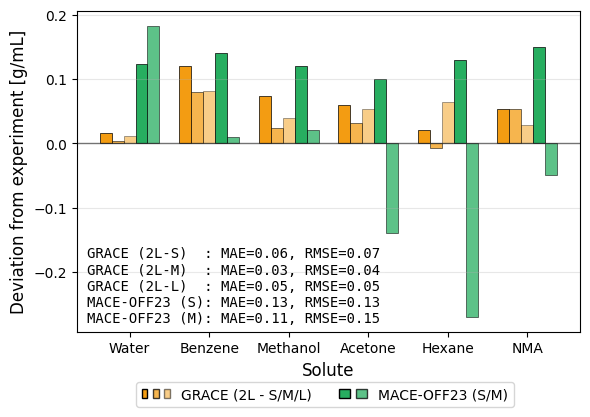

In [150]:
# Create bar plot showing difference to experimental values
fig, ax = plt.subplots(figsize=(6, 4))

# Helper to determine model type key (matching model_type_colors from cell 2)
def get_model_type_key(model_name):
    if "MACE" in model_name:
        return "MACE"
    elif "(1L-" in model_name:
        return "GRACE_1L"
    else:
        return "GRACE_2L"

# Helper to determine size category
def get_size_cat(model_name):
    if "(2L-S)" in model_name or "(1L-S)" in model_name or "(S)" in model_name:
        return "S"
    elif "(2L-M)" in model_name or "(1L-M)" in model_name or "(M)" in model_name:
        return "M"
    elif "(2L-L)" in model_name or "(1L-L)" in model_name or "(L)" in model_name:
        return "L"
    return "S"

# Get experimental data
exp_data = df_clean[df_clean["model"] == "experiment"]
# Include all models except experiment
model_data = df_clean[df_clean["model"] != "experiment"]

# Get unique solutes and models
solutes = exp_data["solute"].unique()
models = model_data["model"].unique()

# Calculate differences for each model and solute
differences_data = []

for model in models:
    model_subset = model_data[model_data["model"] == model]
    mtype = get_model_type_key(model)
    size_cat = get_size_cat(model)
    color = model_type_colors[mtype]
    alpha = size_alpha[size_cat]

    for solute in solutes:
        exp_val = exp_data[exp_data["solute"] == solute]["density"].values
        mod_val = model_subset[model_subset["solute"] == solute]["density"].values

        if len(exp_val) > 0 and len(mod_val) > 0:
            exp_v = exp_val[0]
            mod_v = mod_val[0]

            if pd.notna(exp_v) and pd.notna(mod_v):
                diff = mod_v - exp_v
                differences_data.append(
                    {
                        "model": model,
                        "solute": solute,
                        "difference": diff,
                        "color": color,
                        "alpha": alpha,
                    }
                )

# Create DataFrame for plotting
df_diff = pd.DataFrame(differences_data)

# Create grouped bar plot
x = np.arange(len(solutes))
width = 0.15
offsets = np.linspace(
    -width * (len(models) - 1) / 2, width * (len(models) - 1) / 2, len(models)
)

for i, model in enumerate(models):
    model_data_subset = df_diff[df_diff["model"] == model]
    values = []

    mtype = get_model_type_key(model)
    size_cat = get_size_cat(model)
    color = model_type_colors[mtype]
    alpha = size_alpha[size_cat]

    for solute in solutes:
        solute_data = model_data_subset[model_data_subset["solute"] == solute]
        if len(solute_data) > 0:
            values.append(solute_data["difference"].values[0])
        else:
            values.append(0)

    # Add hatch pattern for MACE models
    hatch = None # "///" if "M" in size_cat else None

    ax.bar(
        x + offsets[i],
        values,
        width,
        color=color,
        alpha=alpha,
        hatch=hatch,
        edgecolor="black",
        linewidth=0.5,
    )

# Add zero line
ax.axhline(y=0, color="black", linestyle="-", linewidth=1, alpha=0.5)

ax.set_ylabel("Deviation from experiment [g/mL]", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(solutes, rotation=0)
ax.grid(axis="y", alpha=0.3)

# Add MAE and RMSE text annotations in bottom left
mae_rmse_text = []
max_len = max(len(model) for model in models)
for model in models:
    model_data_subset = df_diff[df_diff["model"] == model]
    values = []
    for solute in solutes:
        solute_data = model_data_subset[model_data_subset["solute"] == solute]
        if len(solute_data) > 0:
            values.append(solute_data["difference"].values[0])
        else:
            values.append(0)
    mae = np.mean(np.abs(values))
    rmse = np.sqrt(np.mean(np.array(values) ** 2))
    mae_rmse_text.append(f"{model:<{max_len}}: MAE={mae:.2f}, RMSE={rmse:.2f}")

textstr = "\n".join(mae_rmse_text)
props = dict(boxstyle="round", facecolor="white", alpha=0.1, edgecolor="white")
ax.text(
    0.02,
    0.02,
    textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="bottom",
    bbox=props,
    family="monospace",
)

ax.set_xlabel("Solute", fontsize=12)


size_tuple_2l = (
    Patch(facecolor=model_type_colors["GRACE_2L"],edgecolor="black", alpha=1.0),
    Patch(facecolor=model_type_colors["GRACE_2L"], edgecolor="black", alpha=0.75),
    Patch(facecolor=model_type_colors["GRACE_2L"], edgecolor="black", alpha=0.5),
)

size_tuple_mace = (
    Patch(facecolor=model_type_colors["MACE"], edgecolor="black", alpha=1.0),
    Patch(facecolor=model_type_colors["MACE"], edgecolor="black", alpha=0.75),
)

legend_elements = [
    size_tuple_2l,
    size_tuple_mace,
]

# fig.legend(
#     handles=legend_elements,
#     labels=["GRACE (1L - S/M/L)", "GRACE (2L - S/M/L)", "MACE ( S/M/L )"],
#     loc="lower center",
#     ncol=3,
#     bbox_to_anchor=(0.5, -0.02),
#     fontsize=14,
#     frameon=True,
#     handler_map={tuple: HandlerTuple(ndivide=None)},
# )

fig.legend(
    handles=legend_elements,
    labels=["GRACE (2L - S/M/L)", "MACE-OFF23 (S/M)"],
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.55, -0.05),
    fontsize=10,
    frameon=True,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)

plt.tight_layout()
plt.savefig("densities_all_solutes.pdf", bbox_inches="tight")
plt.show()

In [137]:
traj = {
    "GRACE (2L-S)": "traj/traj_water_npt_300_2l_grace_small.pdb",
    "GRACE (2L-M)": "traj/traj_water_npt_300_2l_grace_medium.pdb",
    "GRACE (2L-L)": "traj/traj_water_npt_300_2l_grace_large.pdb",
}


model_rdf = dict()

for model, path in traj.items():

    u = mda.Universe(path)

    irdf2 = dict()

    oxygen = u.select_atoms("name O*")
    hydrogen = u.select_atoms("name H*")

    for i, combination in enumerate(["o-o", "o-h", "h-h"]):
        if combination == "o-o":
            group1 = oxygen
            group2 = oxygen
            exclusion_block = (1, 1)
        elif combination == "o-h":
            group1 = oxygen
            group2 = hydrogen
            exclusion_block = (1, 2)
        elif combination == "h-h":
            group1 = hydrogen
            group2 = hydrogen
            exclusion_block = (2, 2)

        irdf2[combination] = InterRDF(
            group1,
            group2,
            nbins=75,  # default
            range=(0.0, 12.0),  # distance in angstroms
            exclusion_block=exclusion_block,  # exclude intramolecular pairs
        )
        irdf2[combination].run(step=100)

    model_rdf[path] = irdf2

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.9/site-packages/MDAnalysis/analysis/base.py:447: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[i] = ts.time


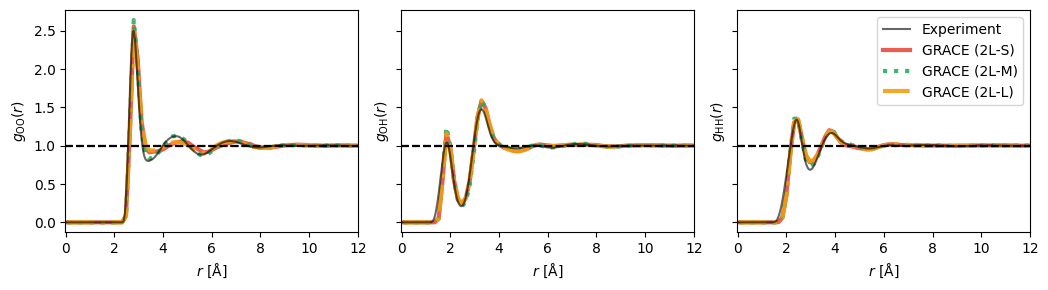

In [138]:
# water data ----------------------------------

exp_water = pd.read_csv("../data/exp_data/exp_water.dat", delimiter="\t")
r_A = exp_water[" r[A] "]
rdf_exp_OO = exp_water["O–O "]
rdf_exp_Oh = exp_water["O–H "]
rdf_exp_hh = exp_water["H–H "]
xlim_lower, xlim_upper = -0.2, 10

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3), sharey=True)
axes[0].plot(
    r_A,
    rdf_exp_OO,
    label="Experiment",
    color="black",
    linewidth=1.5,
    linestyle="-",
    zorder=10,
    alpha=0.6,
)
axes[1].plot(
    r_A,
    rdf_exp_Oh,
    label="Experiment",
    color="black",
    linewidth=1.5,
    linestyle="-",
    zorder=10,
    alpha=0.6,
)
axes[2].plot(
    r_A,
    rdf_exp_hh,
    label="Experiment",
    color="black",
    linewidth=1.5,
    linestyle="-",
    zorder=10,
    alpha=0.6,
)


ylabel_map = {
    "o-o": r"$g_{\mathrm{OO}}(r)$",
    "o-h": r"$g_{\mathrm{OH}}(r)$",
    "h-h": r"$g_{\mathrm{HH}}(r)$",
}

# Extract size from model name for color mapping and assign different line styles
model_colors = {}
model_linestyles = {}
linestyles = ["-", ":", "-.", ":"]  # solid, dashed, dash-dot, dotted
for idx, model in enumerate(traj.keys()):
    if "S" in model:
        model_colors[model] = size_colors["small"]
    elif "M" in model:
        model_colors[model] = size_colors["medium"]
    elif "2L-L" in model:
        model_colors[model] = size_colors["large"]
    model_linestyles[model] = linestyles[idx % len(linestyles)]

for model, path in traj.items():
    rdf = model_rdf[path]
    for i, combination in enumerate(["o-o", "o-h", "h-h"]):

        axes[i].plot(
            rdf[combination].results.bins,
            rdf[combination].results.rdf,
            label=model,
            color=model_colors[model],
            linestyle=model_linestyles[model],
            alpha=0.9,
            linewidth=3.0,
        )
        axes[i].axhline(y=1, color="k", linestyle="--")
        axes[i].set_xlabel(r"$r$ [Å]")
        axes[i].set_ylabel(ylabel_map[combination])
        axes[i].set_xlim(-0.01, 12)
        axes[2].legend()


plt.tight_layout()
plt.savefig("waterbox_rdf.pdf")
plt.show()

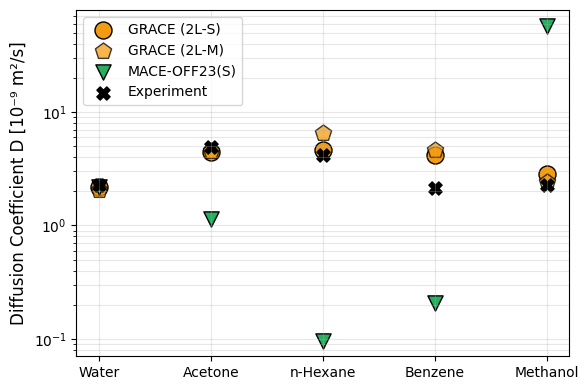

In [140]:
df_diffusion = pd.read_csv("diffusion/diffusion_results.csv")
df_diffusion["solute"] = df_diffusion["solute"].replace("Hexane", "n-Hexane")
df_diffusion["model"] = df_diffusion["model"].replace("GRACE SMALL", "GRACE (2L-S)")
df_diffusion["model"] = df_diffusion["model"].replace("GRACE MEDIUM", "GRACE (2L-M)")
df_diffusion_dropped = df_diffusion  # .drop(16)


# Create a scatter plot with solutes on x-axis and models as different series
fig, ax = plt.subplots(figsize=(6, 4))

# Get unique models and solutes
models = df_diffusion_dropped["model"].unique()
solutes = df_diffusion_dropped["solute"].unique()

# Define colors using model_type_colors and size_alpha from cell 2
colors = {
    "GRACE (2L-S)": model_type_colors["GRACE_2L"],
    "GRACE (2L-M)": model_type_colors["GRACE_2L"],
    "Experiment": "black",
    "MACE-OFF23(S)": model_type_colors["MACE"],
}
alphas = {
    "GRACE (2L-S)": size_alpha["S"],
    "GRACE (2L-M)": size_alpha["M"],
    "Experiment": 1.0,
    "MACE-OFF23(S)": size_alpha["S"],
}


# Plot each model
for model in models:
    model_data = df_diffusion_dropped[df_diffusion_dropped["model"] == model]
    if "Experiment" in model:
        size = 90
    else:
        size = 150
    # Add hatch pattern for MACE models
    if "MACE" in model:
        ax.scatter(
            model_data["solute"],
            model_data["D_m2_s"] * 10**9,
            label=model,
            color=colors.get(model, "gray"),
            marker=markers.get(model, "o"),
            edgecolors="black",
            alpha=alphas.get(model, 0.9),
            s=120,
            # hatch="///",
        )
    else:
        ax.scatter(
            model_data["solute"],
            model_data["D_m2_s"] * 10**9,
            label=model,
            color=colors.get(model, "gray"),
            marker=markers.get(model, "o"),
            edgecolors="black",
            alpha=alphas.get(model, 0.9),
            s=size,
        )

ax.set_ylabel("Diffusion Coefficient D [10⁻⁹ m²/s]", fontsize=12)
ax.set_yscale("log")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which="both")


plt.tight_layout()
plt.savefig("diffusion_values_all.pdf")

/tmp/ipykernel_2455390/1242044874.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(
/tmp/ipykernel_2455390/1242044874.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
/tmp/ipykernel_2455390/1242044874.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df3 = pd.read_csv(


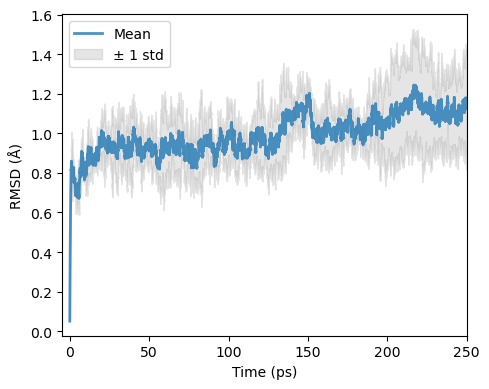

In [ ]:
# Read data
df1 = pd.read_csv(
    "rdf/rmsd_run1.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"]
)
df2 = pd.read_csv(
    "rdf/rmsd_run2.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"]
)
df3 = pd.read_csv(
    "rdf/rmsd_run3.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"]
)

# Combine data
frames = df1["frame"].values
rmsd1 = df1["rmsd"].values
rmsd2 = df2["rmsd"].values
rmsd3 = df3["rmsd"].values

# Calculate mean and standard deviation
rmsd_mean = (rmsd1 + rmsd2 + rmsd3) / 3
rmsd_std = np.sqrt(
    ((rmsd1 - rmsd_mean) ** 2 + (rmsd2 - rmsd_mean) ** 2 + (rmsd3 - rmsd_mean) ** 2) / 2
)

# Create plot
plt.figure(figsize=(5, 4))
plt.plot(frames / 100, rmsd_mean, "C0", linewidth=2, label="Mean", alpha=0.8)
plt.fill_between(
    frames / 100,
    rmsd_mean - rmsd_std,
    rmsd_mean + rmsd_std,
    color="gray",
    alpha=0.2,
    label="± 1 std",
)
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend()
plt.xlim([-5, 250])
plt.tight_layout()
plt.savefig("crambin_rmsd.pdf")

/tmp/ipykernel_2455390/3490350207.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(
/tmp/ipykernel_2455390/3490350207.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(
/tmp/ipykernel_2455390/3490350207.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df3 = pd.read_csv(


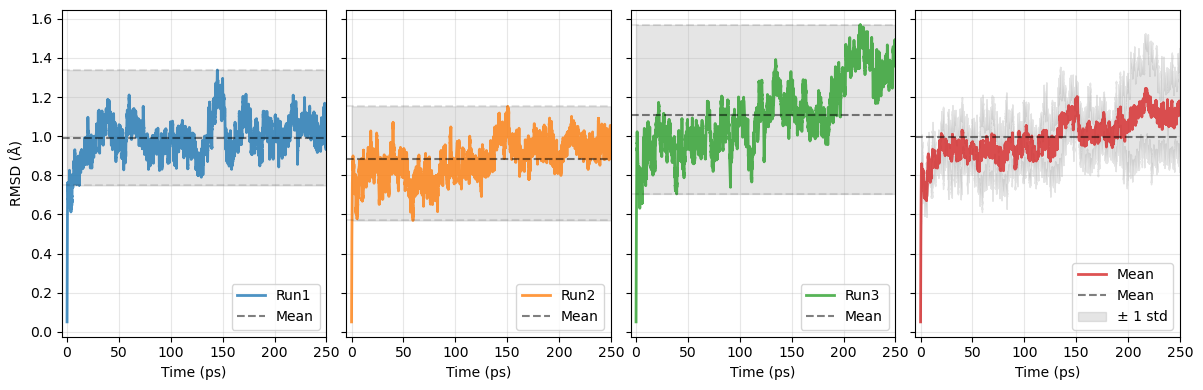

In [33]:
# Read data
df1 = pd.read_csv(
    "rdf/rmsd_run1.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"]
)
df2 = pd.read_csv(
    "rdf/rmsd_run2.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"]
)
df3 = pd.read_csv(
    "rdf/rmsd_run3.dat", delim_whitespace=True, comment="#", names=["frame", "rmsd"]
)

# Combine data
frames = df1["frame"].values
rmsd1 = df1["rmsd"].values
rmsd2 = df2["rmsd"].values
rmsd3 = df3["rmsd"].values

# Calculate mean and standard deviation
rmsd_mean = (rmsd1 + rmsd2 + rmsd3) / 3
rmsd_std = np.sqrt(
    ((rmsd1 - rmsd_mean) ** 2 + (rmsd2 - rmsd_mean) ** 2 + (rmsd3 - rmsd_mean) ** 2) / 2
)

fig, axs = plt.subplots(1, 4, figsize=(12, 4), sharey=True)

axs[0].plot(frames / 100, rmsd1, "C0", linewidth=2, label="Run1", alpha=0.8)
axs[0].set_ylabel("RMSD (Å)")
axs[0].axhline(y=rmsd1.mean(), color="k", linestyle="--", alpha=0.5, label="Mean")
axs[0].axhline(y=rmsd1.max(), color="k", linestyle="--", alpha=0.1)
axs[0].axhline(y=rmsd1[1000:].min(), color="k", linestyle="--", alpha=0.1)
axs[0].fill_between(
    frames / 100,
    rmsd1[1000:].min(),
    rmsd1.max(),
    color="gray",
    alpha=0.2,
)


axs[1].plot(frames / 100, rmsd2, "C1", linewidth=2, label="Run2", alpha=0.8)
axs[1].axhline(y=rmsd2.mean(), color="k", linestyle="--", alpha=0.5, label="Mean")
axs[1].axhline(y=rmsd2.max(), color="k", linestyle="--", alpha=0.1)
axs[1].axhline(y=rmsd2[1000:].min(), color="k", linestyle="--", alpha=0.1)
axs[1].fill_between(
    frames / 100,
    rmsd2[1000:].min(),
    rmsd2.max(),
    color="gray",
    alpha=0.2,
)

axs[2].plot(frames / 100, rmsd3, "C2", linewidth=2, label="Run3", alpha=0.8)
axs[2].axhline(y=rmsd3.mean(), color="k", linestyle="--", alpha=0.5, label="Mean")
axs[2].axhline(y=rmsd3.max(), color="k", linestyle="--", alpha=0.1)
axs[2].axhline(y=rmsd3[1000:].min(), color="k", linestyle="--", alpha=0.1)
axs[2].fill_between(
    frames / 100,
    rmsd3[1000:].min(),
    rmsd3.max(),
    color="gray",
    alpha=0.2,
)

axs[3].plot(frames / 100, rmsd_mean, "C3", linewidth=2, label="Mean", alpha=0.8)
axs[3].axhline(y=rmsd_mean.mean(), color="k", linestyle="--", alpha=0.5, label="Mean")
axs[3].fill_between(
    frames / 100,
    rmsd_mean - rmsd_std,
    rmsd_mean + rmsd_std,
    color="gray",
    alpha=0.2,
    label="± 1 std",
)
for ax in axs:
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")
    ax.set_xlabel("Time (ps)")
    ax.set_xlim([-5, 250])

plt.tight_layout()
plt.savefig("crambin_rmsd_single_runs.pdf")

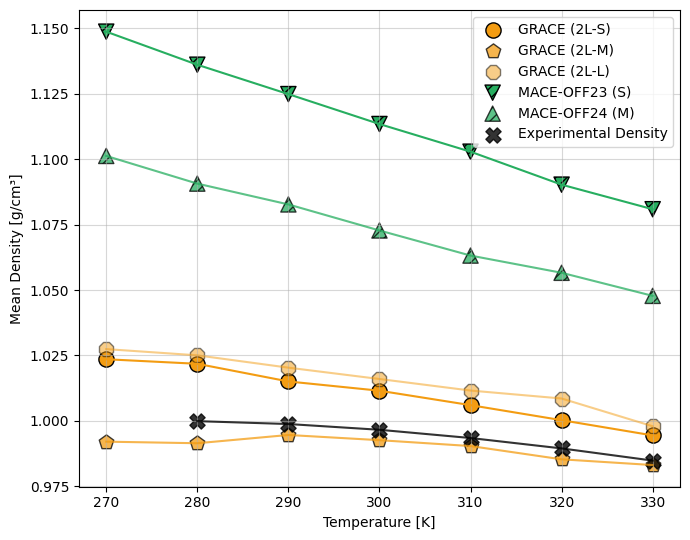

In [157]:
# --- Read the CSV ---
mean_data = pd.read_csv("temp_density/all_density_means.csv")
mean_data = mean_data[1:]

# --- Define styles for each column (except Temperature) ---
plot_styles = {
    "GRACE (2L-S)": {
        "color": model_type_colors["GRACE_2L"],
        "marker": markers["GRACE (2L-S)"],
        "alpha": size_alpha["S"],
        "label": "GRACE (2L-S)",
    },
    "GRACE (2L-M)": {
        "color": model_type_colors["GRACE_2L"],
        "marker": markers["GRACE (2L-M)"],
        "alpha": size_alpha["M"],
        "label": "GRACE (2L-M)",
    },
    "GRACE (2L-L)": {
        "color": model_type_colors["GRACE_2L"],
        "marker": markers["GRACE (2L-L)"],
        "alpha": size_alpha["L"],
        "label": "GRACE (2L-L)",
    },
    "MACE (S)": {
        "color": model_type_colors["MACE"],
        "marker": markers["MACE-OFF23(S)"],
        "alpha": size_alpha["S"],
        "label": "MACE-OFF23 (S)",
    },
    "MACE (M)": {
        "color": model_type_colors["MACE"],
        "marker": markers["MACE-OFF23(M)"],
        "alpha": size_alpha["M"],
        "label": "MACE-OFF24 (M)",
    },
    "Experimental": {
        "color": "black",
        "marker": markers["Experiment"],
        "alpha": 0.8,
        "label": "Experimental Density",
    },
}

plt.figure(figsize=(7, 5.5))

# --- Loop over columns to plot ---
for col, style in plot_styles.items():
    temps = mean_data["Temperature_K"]
    values = mean_data[col]

    plt.scatter(
        temps,
        values,
        color=style["color"],
        marker=style["marker"],
        edgecolor="k" if col != "Experimental" else None,
        s=120,
        label=style["label"],
        alpha=style["alpha"],
        hatch="///" if "MACE" in col else None,
    )

    plt.plot(temps, values, color=style["color"], alpha=style["alpha"])

# --- Final plot formatting ---
plt.xticks([270, 280, 290, 300, 310, 320, 330])
plt.xlabel("Temperature [K]")
plt.ylabel("Mean Density [g/cm³]")
plt.grid(True, alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("density_vs_temperature.pdf")
plt.show()

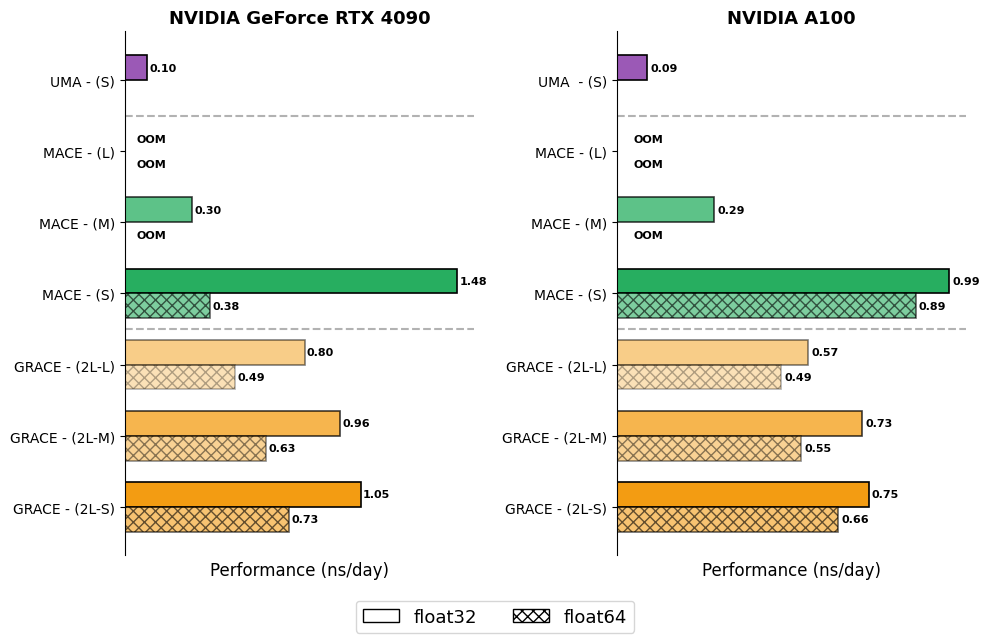

In [154]:
data = pd.read_csv("speedTest/speed_test_results.csv")
# Sort: GRACE first, then MACE, then UMA; within each, small -> medium -> large
size_order = {"(2L-S)": 0, "(S)": 0, "(2L-M)": 1, "(M)": 1, "(2L-L)": 2, "(L)": 2}
model_order = {"GRACE": 0, "MACE": 1, "UMA": 2}
data["size_order"] = data["model_size"].map(size_order)
data["model_order"] = data["model_type"].map(model_order)
sorted_data = data.sort_values(["model_order", "size_order"], ascending=[True, True])

# Helper to get model type color and size alpha
def get_bar_style(config_str):
    # Determine model type
    if "MACE" in config_str:
        color = model_type_colors["MACE"]
    elif "GRACE" in config_str:
        color = model_type_colors["GRACE_2L"]
    elif "UMA" in config_str:
        color = model_type_colors.get("UMA", "#9b59b6")
    else:
        color = "gray"
    
    # Determine size alpha
    if "(2L-S)" in config_str or "(S)" in config_str:
        alpha = size_alpha["S"]
    elif "(2L-M)" in config_str or "(M)" in config_str:
        alpha = size_alpha["M"]
    elif "(2L-L)" in config_str or "(L)" in config_str:
        alpha = size_alpha["L"]
    else:
        alpha = 1.0
    
    return color, alpha

# Create 1x3 subplot for each GPU
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=False)

# Process each GPU
# gpu_names = ["NVIDIA A40", "NVIDIA L40S", "NVIDIA RTX 6000 Ada Generation"]
gpu_names = ["NVIDIA GeForce RTX 4090", "NVIDIA A100"]
for idx, gpu_name in enumerate(gpu_names):
    ax = axes[idx]

    # Filter data for this GPU
    gpu_data = sorted_data[sorted_data["gpu_name"] == gpu_name].copy()

    # Get unique model configurations (model_type + model_size)
    gpu_data["config"] = gpu_data["model_type"] + " - " + gpu_data["model_size"]
    configs = gpu_data["config"].unique()

    # Find separator positions between architectures
    separator_positions = []
    for i in range(len(configs) - 1):
        # Extract model type from config strings
        type_curr = configs[i].split(" - ")[0]
        type_next = configs[i + 1].split(" - ")[0]
        if type_curr != type_next:
            separator_positions.append(i + 0.5)

    # Create positions for bars
    y_pos = np.arange(len(configs))
    bar_height = 0.35

    # Plot bars for each dtype
    for dtype_idx, dtype in enumerate(["float32", "float64"]):
        dtype_data = gpu_data[gpu_data["default_dtype"] == dtype]

        # Get performance values for this dtype
        perf_values = []
        bar_styles = []
        oom_flags = []  # Track which configs are OOM
        for config in configs:
            config_data = dtype_data[dtype_data["config"] == config]
            
            # Check for OOM cases
            is_oom = False
            if "MACE" in config and "(L)" in config:
                is_oom = True
            elif "MACE" in config and "(M)" in config and dtype == "float64":
                is_oom = True
            
            oom_flags.append(is_oom)
            color, alpha_size = get_bar_style(config)
            bar_styles.append((color, alpha_size))
            
            if len(config_data) > 0 and not is_oom:
                perf_values.append(config_data["ns_per_day"].values[0])
            else:
                perf_values.append(0)

        # Offset bars
        offset = bar_height / 2 if dtype == "float32" else -bar_height / 2

        # Hatching based on dtype: float64 gets hatching
        hatch = "xxx" if dtype == "float64" else None

        # Create bars — use dtype-based alpha modifier on top of size alpha
        dtype_alpha_mod = 1.0 if dtype == "float32" else 0.6
        for i, (val, (color, alpha_size), is_oom) in enumerate(zip(perf_values, bar_styles, oom_flags)):
            ax.barh(
                y_pos[i] + offset,
                val,
                bar_height,
                color=color,
                alpha=alpha_size * dtype_alpha_mod,
                edgecolor="black",
                linewidth=1.2,
                hatch=hatch,
                label=dtype if i == 0 else "",
            )

        # Add value labels on bars (or OOM text)
        for i, (val, is_oom) in enumerate(zip(perf_values, oom_flags)):
            if is_oom:
                ax.text(
                    0.05,
                    y_pos[i] + offset,
                    "OOM",
                    ha="left",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color="black",
                )
            elif val > 0:
                ax.text(
                    val + 0.01,
                    y_pos[i] + offset,
                    f"{val:.2f}",
                    ha="left",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                )

    # Set labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(configs, fontsize=10)
    ax.set_xlabel("Performance (ns/day)", fontsize=12)
    ax.set_title(gpu_name, fontsize=13, fontweight="bold")

    # Remove top and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # Remove x-axis ticks and labels
    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Add separator lines between architectures (GRACE/MACE/UMA)
    for pos in separator_positions:
        ax.axhline(y=pos, color="gray", linestyle="--", linewidth=1.5, alpha=0.6)

# Create legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="white", edgecolor="black", label="float32"),
    Patch(facecolor="white", edgecolor="black", hatch="xxx", label="float64"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=7,
    fontsize=13,
)

plt.tight_layout()
plt.savefig("compPerformance.pdf", bbox_inches="tight")
plt.show()

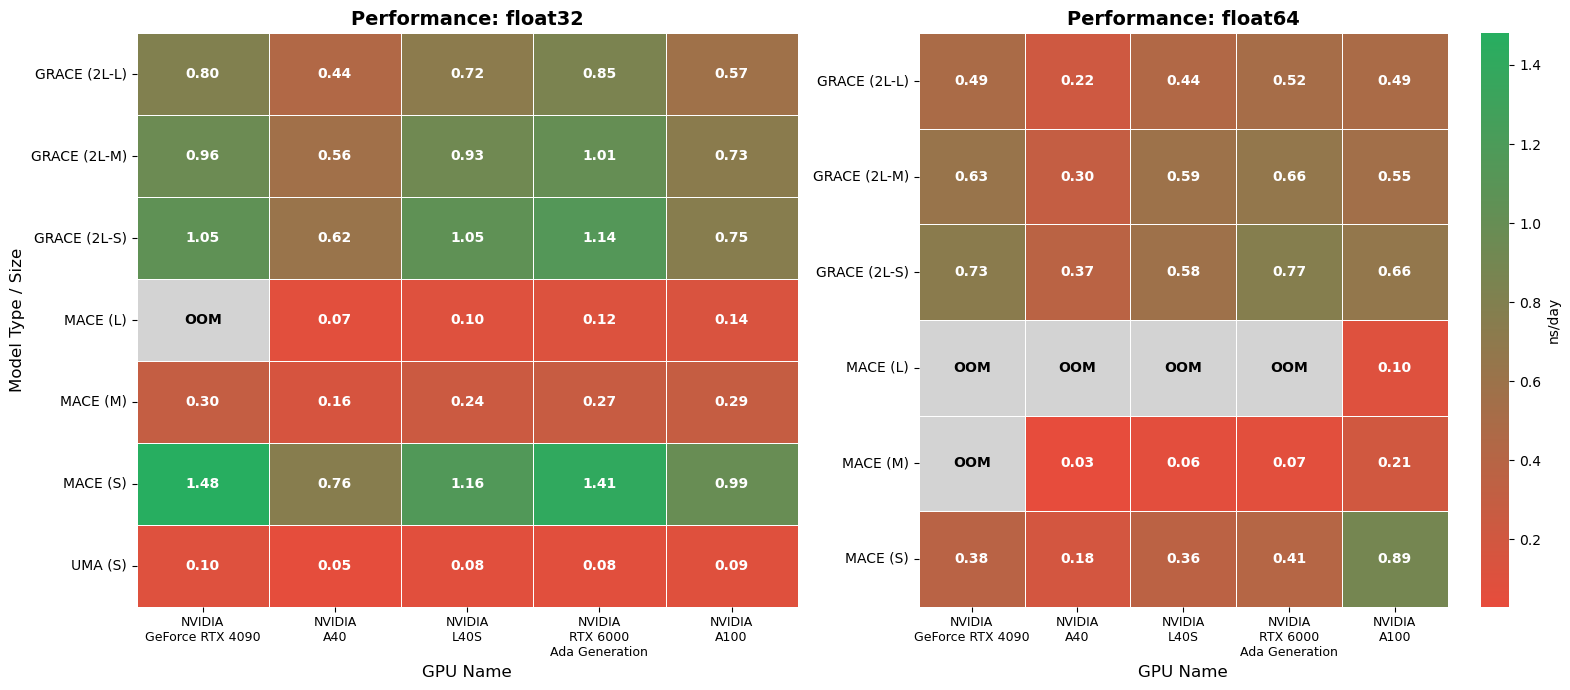

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

# Create a custom colormap using the size_colors (red -> green)
custom_cmap = LinearSegmentedColormap.from_list(
    'size_cmap', 
    [size_colors['small'], size_colors['medium']]  # red to green
)

# Create a combined model label (model_type + model_size)
# Normalize whitespace to combine entries like "UMA  (S)" and "UMA (S)"
data['model_label'] = (data['model_type'].str.strip() + ' ' + data['model_size'].str.strip()).str.replace(r'\s+', ' ', regex=True)

# Define GPU order from cheapest/smallest to highest performing
gpu_order = [
    'NVIDIA GeForce RTX 4090',
    'NVIDIA A40',
    'NVIDIA L40S',
    'NVIDIA RTX 6000 Ada Generation',
    'NVIDIA A100'
]

# Create figure with two subplots and shared colorbar
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Get global min/max for consistent colorbar across both plots
vmin = data['ns_per_day'].min()
vmax = data['ns_per_day'].max()

for idx, dtype in enumerate(['float32', 'float64']):
    ax = axes[idx]
    
    # Filter data for this dtype
    dtype_data = data[data['default_dtype'] == dtype]
    
    # Pivot the data to create a matrix for the heatmap
    heatmap_data = dtype_data.pivot_table(
        values='ns_per_day', 
        index='model_label', 
        columns='gpu_name', 
        aggfunc='mean'
    )
    
    # Reorder columns based on GPU order (only include GPUs that exist in data)
    available_gpus = [gpu for gpu in gpu_order if gpu in heatmap_data.columns]
    heatmap_data = heatmap_data[available_gpus]
    
    # Use mask for NaN values to show them with a different color
    mask = heatmap_data.isna()
    
    # First, plot a gray background for OOM cells
    sns.heatmap(
        heatmap_data.fillna(0), 
        annot=False,
        cmap=ListedColormap(['#d3d3d3']),  # Light gray for OOM
        mask=~mask,  # Only show where data is missing
        ax=ax,
        linewidths=0.5,
        linecolor='black',
        cbar=False
    )
    
    # Then overlay the actual data (without annotations for now)
    sns.heatmap(
        heatmap_data, 
        annot=True, 
        fmt='.2f', 
        cmap=custom_cmap, 
        cbar=(idx == 1),  # Only show colorbar on right plot
        cbar_kws={'label': 'ns/day'} if idx == 1 else {},
        ax=ax,
        linewidths=0.5,
        linecolor='white',
        vmin=vmin,
        vmax=vmax,
        annot_kws={'fontsize': 10, 'fontweight': 'bold'}
    )
    
    # Manually add "OOM" text for NaN cells
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            if pd.isna(heatmap_data.iloc[i, j]):
                ax.text(j + 0.5, i + 0.5, "OOM", 
                       ha='center', va='center', 
                       fontsize=10, fontweight='bold', color='black')
    
    ax.set_xlabel('GPU Name', fontsize=12)
    ax.set_ylabel('Model Type / Size', fontsize=12) if idx == 0 else ax.set_ylabel('')
    ax.set_title(f'Performance: {dtype}', fontsize=14, fontweight='bold')
    
    # Format x-axis labels with multiple lines (no rotation)
    x_labels = [label.get_text().replace('NVIDIA ', 'NVIDIA\n').replace(' Ada Generation', '\nAda Generation') 
                for label in ax.get_xticklabels()]
    ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("compPerformance_matrix.pdf")
plt.show()

In [143]:
# Dictionary containing all properties for different models
properties_data = {
    'Experiment': {
        'Heat capacity (cal/K/mol)': 1.0,
        'Isothermal compressibility (*1e4/bar)': 0.45,
        'Thermal expansion (*1e2/K)': 0.03,
        'Heat of vaporization (kJ/mol)': 43.99,
        'Density (g/mL)': 0.997,
    },
    'GRACE\n(2L-S)': {
        'Heat capacity (cal/K/mol)': 1.61,
        'Isothermal compressibility (*1e4/bar)': 0.45,
        'Thermal expansion (*1e2/K)': 0.05,
        'Heat of vaporization (kJ/mol)': 42.36,
        'Density (g/mL)': 1.01,
    },
    'GRACE\n(2L-M)': {
        'Heat capacity (cal/K/mol)': 1.58,
        'Isothermal compressibility (*1e4/bar)': 0.42,
        'Thermal expansion (*1e2/K)': 0.01,
        'Heat of vaporization (kJ/mol)': 43.31,
        'Density (g/mL)': 1.00,
    },
    'GRACE\n(2L-L)': {
        'Heat capacity (cal/K/mol)': 1.50,
        'Isothermal compressibility (*1e4/bar)': 0.46,
        'Thermal expansion (*1e2/K)': 0.05,
        'Heat of vaporization (kJ/mol)': 43.10,
        'Density (g/mL)': 1.01,
    },
    'MACE-\nOFF23(S)': {
        'Heat capacity (cal/K/mol)': 1.71,
        'Isothermal compressibility (*1e4/bar)': 0.29,
        'Thermal expansion (*1e2/K)': 0.10,
        'Heat of vaporization (kJ/mol)': 47.80,
        'Density (g/mL)': 1.12,
    },
    'MACE-\nOFF24(M)': {
        'Heat capacity (cal/K/mol)': 1.42,
        'Isothermal compressibility (*1e4/bar)': 0.41,
        'Thermal expansion (*1e2/K)': 0.08,
        'Heat of vaporization (kJ/mol)': 47.47,
        'Density (g/mL)': 1.08,
    },
    'MACE-\nOFF23(M)': {
        'Heat capacity (cal/K/mol)': 1.57,
        'Isothermal compressibility (*1e4/bar)': 0.23,
        'Thermal expansion (*1e2/K)': 0.06,
        'Heat of vaporization (kJ/mol)': 48.90,
        'Density (g/mL)': 1.18,
    },
    'UMA/\nOMol25': {
        'Heat capacity (cal/K/mol)': 1.54,
        'Isothermal compressibility (*1e4/bar)': 0.34,
        'Thermal expansion (*1e2/K)': 0.07,
        'Heat of vaporization (kJ/mol)': 50.38,
        'Density (g/mL)': 1.11,
    },
}

# import pickle

# with open('condensed_phase/properties_data_water.pkl', 'wb') as f:
#     pickle.dump(properties_data, f)

In [144]:
# load pickl file
# with open("condensed_phase/properties_data_water.pkl", "rb") as f:
#     properties_data = pickle.load(f)

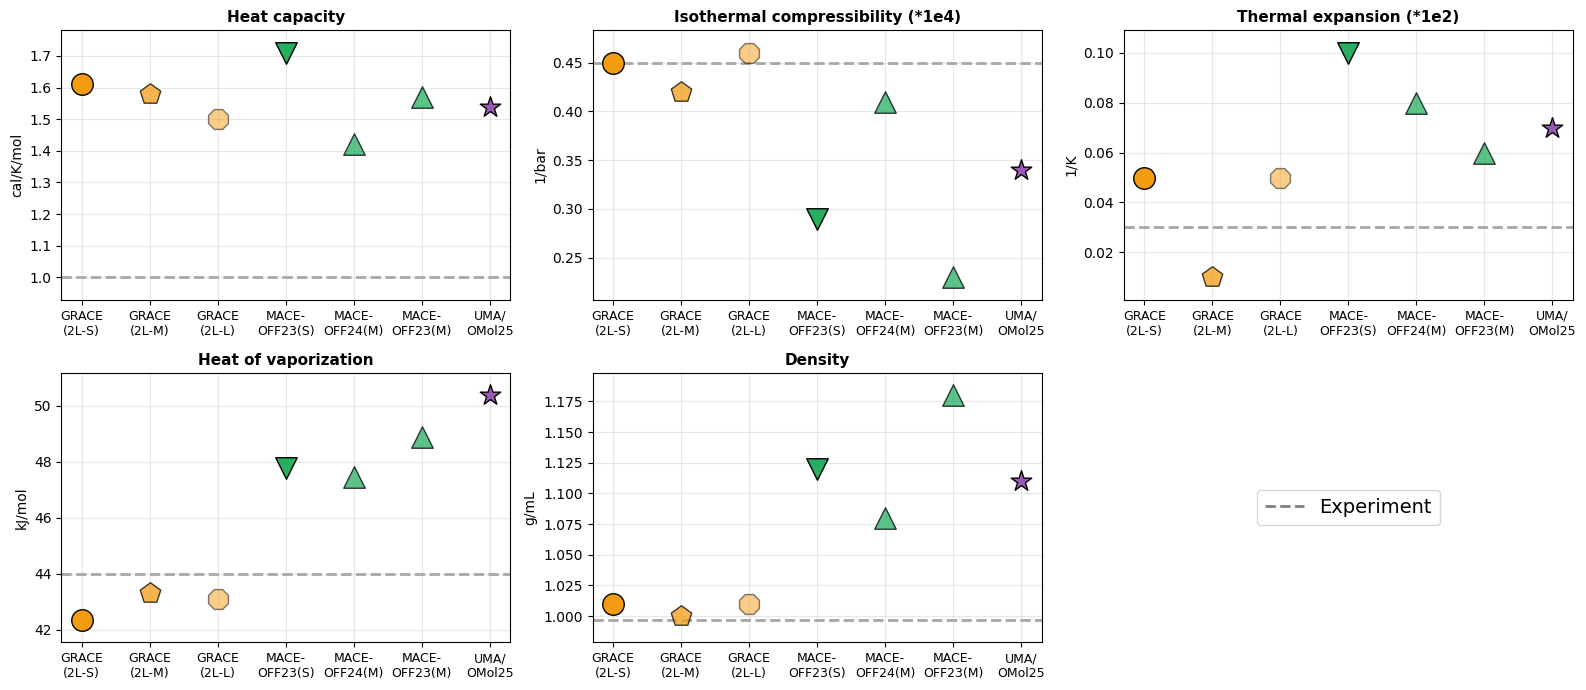

In [145]:
# Create subplots for each property
properties_config = [
    {"name": "Heat capacity", "unit": "cal/K/mol"},
    {"name": "Isothermal compressibility (*1e4)", "unit": "1/bar"},
    {"name": "Thermal expansion (*1e2)", "unit": "1/K"},
    {"name": "Heat of vaporization", "unit": "kJ/mol"},
    {"name": "Density", "unit": "g/mL"},
]

# Original property keys for data access
properties = [
    "Heat capacity (cal/K/mol)",
    "Isothermal compressibility (*1e4/bar)",
    "Thermal expansion (*1e2/K)",
    "Heat of vaporization (kJ/mol)",
    "Density (g/mL)",
]

# Extract model names (excluding Experiment)
models = [model for model in properties_data.keys() if model != "Experiment"]

# Map model names (with newlines) to marker/color keys
def get_style(model_name):
    if "UMA" in model_name or "OMol" in model_name:
        return model_type_colors["UMA"], markers["UMA (S)"], 1.0, "UMA/OMol"
    # Determine model type color
    if "GRACE" in model_name:
        color = model_type_colors["GRACE_2L"]
        family = "GRACE"
    elif "MACE" in model_name:
        color = model_type_colors["MACE"]
        family = "MACE"
    else:
        color = "gray"
        family = "Unknown"
    
    # Determine size and alpha
    if "(S)" in model_name or "S)" in model_name or "2L-S" in model_name:
        alpha = size_alpha["S"]
        size_label = "S"
    elif "(M)" in model_name or "M)" in model_name or "2L-M" in model_name:
        alpha = size_alpha["M"]
        size_label = "M"
    elif "(L)" in model_name or "L)" in model_name or "2L-L" in model_name:
        alpha = size_alpha["L"]
        size_label = "L"
    else:
        alpha = 1.0
        size_label = "M"
    
    # Determine marker
    if family == "GRACE":
        marker_key = f"GRACE (2L-{size_label})"
    else:
        marker_key = f"MACE-OFF23({size_label})"
    marker = markers.get(marker_key, "o")
    
    label = f"{family} ({size_label})"
    return color, marker, alpha, label


# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

# Track which labels we've already added to avoid duplicates
added_labels = set()

for i, (prop, config) in enumerate(zip(properties, properties_config)):
    ax = axes[i]

    # Get experimental value for horizontal line
    exp_value = properties_data["Experiment"][prop]

    # Get values for each model
    values = [properties_data[model][prop] for model in models]

    # Create x-axis positions
    x = np.arange(len(models))

    # Plot experimental reference line (only add label once)
    if "Experiment" not in added_labels:
        ax.axhline(
            exp_value,
            color="gray",
            linestyle="--",
            linewidth=2,
            label="Experiment",
            alpha=0.7,
            zorder=1,
        )
        added_labels.add("Experiment")
    else:
        ax.axhline(
            exp_value, color="gray", linestyle="--", linewidth=2, alpha=0.7, zorder=1
        )

    # Plot scatter points for models with different colors and markers
    for j, (model, value) in enumerate(zip(models, values)):
        color, marker, alpha, label = get_style(model)

        # Add hatching for MACE models
        hatch = "///" if "MACE" in model else None

        # Only add label if not already added
        if label not in added_labels:
            ax.scatter(
                j,
                value,
                s=240,
                alpha=alpha,
                color=color,
                marker=marker,
                edgecolors="black",
                linewidths=1,
                zorder=3,
                label=label,
                # hatch=hatch,
            )
            added_labels.add(label)
        else:
            ax.scatter(
                j,
                value,
                s=240,
                alpha=alpha,
                color=color,
                marker=marker,
                edgecolors="black",
                linewidths=1,
                zorder=3,
                # hatch=hatch,
            )

    # Customize plot
    ax.set_title(config["name"], fontsize=11, fontweight="bold")
    ax.set_ylabel(config["unit"], fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=0, ha="center", fontsize=9)
    ax.grid(True, alpha=0.3, axis="both")

    # Add slight padding to y-axis
    y_min = min(min(values), exp_value)
    y_max = max(max(values), exp_value)
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)

# Use the 6th subplot position for the legend
axes[5].axis("off")  # Turn off the axis

# Create custom legend with simplified entries
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color="gray", linestyle="--", linewidth=2, label="Experiment"),
    # Line2D(
    #     [0], [0], marker=markers["GRACE (2L-S)"], color="w",
    #     markerfacecolor=model_type_colors["GRACE_2L"], markersize=10,
    #     markeredgecolor="black", linewidth=0, label="GRACE (2L-S)",
    # ),
    # Line2D(
    #     [0], [0], marker=markers["GRACE (2L-M)"], color="w",
    #     markerfacecolor=model_type_colors["GRACE_2L"], markersize=10,
    #     markeredgecolor="black", linewidth=0, label="GRACE (2L-M)",
    # ),
    # Line2D(
    #     [0], [0], marker=markers["GRACE (2L-L)"], color="w",
    #     markerfacecolor=model_type_colors["GRACE_2L"], markersize=10,
    #     markeredgecolor="black", linewidth=0, label="GRACE (2L-L)",
    # ),
    # Line2D(
    #     [0], [0], marker=markers["MACE-OFF23(S)"], color="w",
    #     markerfacecolor=model_type_colors["MACE"], markersize=10,
    #     markeredgecolor="black", linewidth=0, label="MACE-OFF23(S)",
    # ),
    # Line2D(
    #     [0], [0], marker=markers["MACE-OFF23(M)"], color="w",
    #     markerfacecolor=model_type_colors["MACE"], markersize=10,
    #     markeredgecolor="black", linewidth=0, label="MACE (M)",
    # ),
    # Line2D(
    #     [0], [0], marker="*", color="w",
    #     markerfacecolor=uma_color, markersize=14,
    #     markeredgecolor="black", linewidth=0, label="UMA/OMol",
    # ),
]
axes[5].legend(handles=legend_elements, loc="center", fontsize=14, frameon=True)

plt.tight_layout()
plt.savefig("condensed_phase_properties_water.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_2374946/2809681908.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


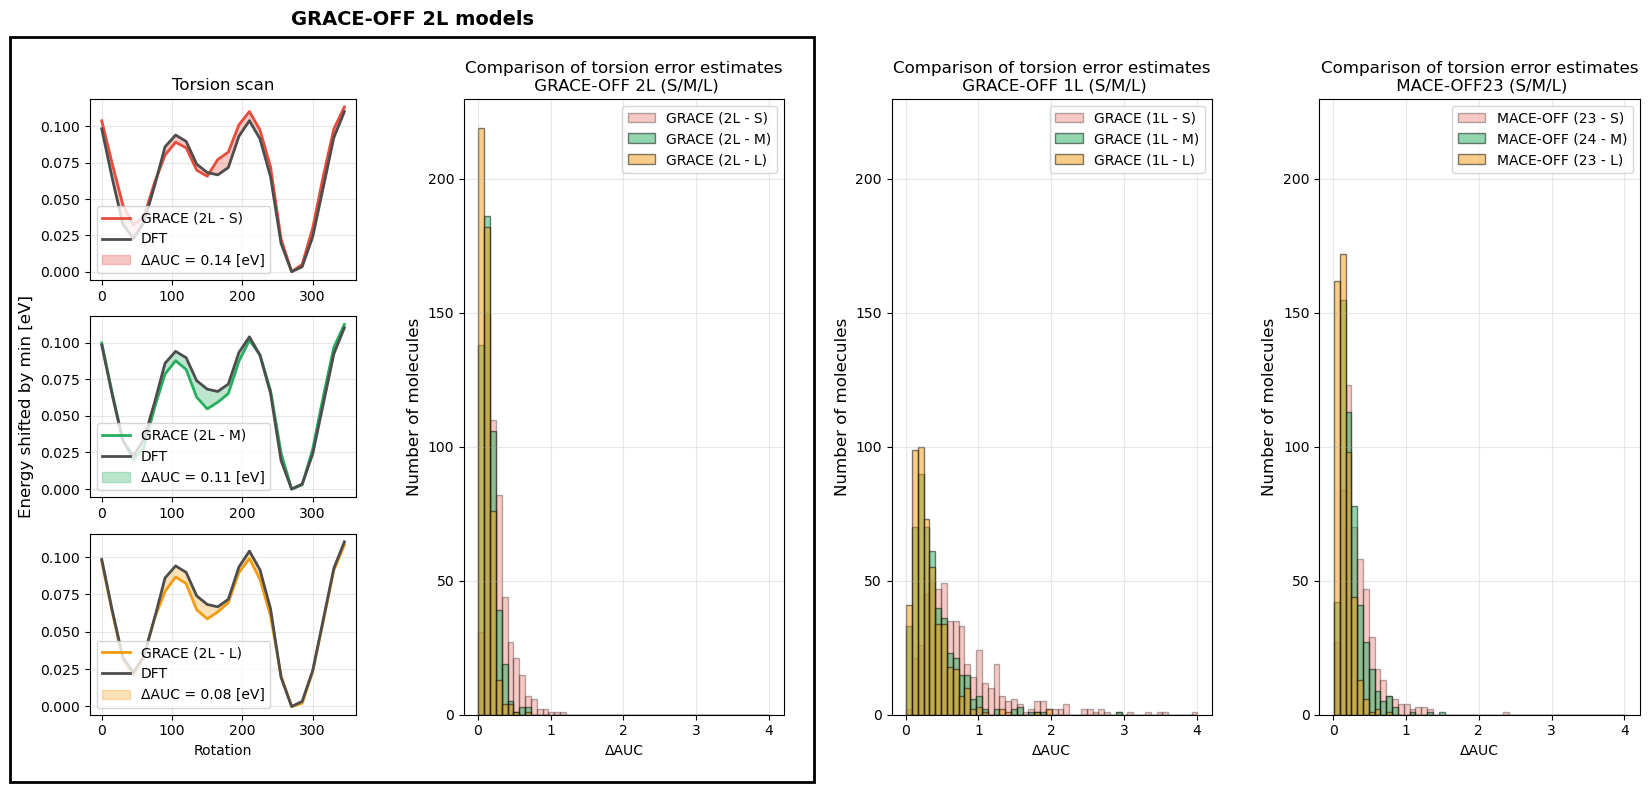

In [6]:
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import h5py

grace_errors_1l_off_s = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_1l_small.csv")
grace_errors_1l_off_m = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_1l_medium.csv")
grace_errors_1l_off_l = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_1l_large.csv")
grace_errors_2l_off_s = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_2l_small.csv")
grace_errors_2l_off_m = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_2l_medium.csv")
grace_errors_2l_off_l = pd.read_csv("torsion_scans/error_files/grace_errors_b_off_2l_large.csv")

mace_errors_s = pd.read_csv("torsion_scans/error_files/mace_errors_small.csv")
mace_errors_m = pd.read_csv("torsion_scans/error_files/mace_errors_medium.csv")
mace_errors_l = pd.read_csv("torsion_scans/error_files/mace_errors_large.csv")


single_torsion = pd.read_csv("torsion_scans/error_files/single_torsion.csv")



# colors from above
color_small = size_colors["small"]   
color_medium = size_colors["medium"]  
color_large = size_colors["large"]    
color_dft = "#4d4d4d"    
data_tnet = h5py.File("../data/TNet500-SPICE.hdf5", "r")
smiles = list(data_tnet.keys())[0]



# prepare data for single torsion plot
torsion_small = np.asarray(single_torsion['small_2l']) - np.min(np.asarray(single_torsion['small_2l']))
torsion_med   = np.asarray(single_torsion['medium_2l']) - np.min(np.asarray(single_torsion['medium_2l']))
torsion_large = np.asarray(single_torsion['large_2l']) - np.min(np.asarray(single_torsion['large_2l']))
dft          = np.asarray(data_tnet[smiles]["dft total energy"]) * 27.211386245988
dft          = dft - np.min(dft)
x = np.arange(len(dft))

area_small = np.trapz(np.abs(torsion_small - dft), x)
area_medium= np.trapz(np.abs(torsion_med - dft), x)
area_large = np.trapz(np.abs(torsion_large - dft), x)

x = np.arange(len(dft))*15

# Layout: 2 rows, 2 columns, right column wider
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(
    3, 4,
    figure=fig,
    width_ratios=[1, 1.2, 1.2, 1.2],
    wspace=0.35   
)


# --- Left upper plot: GRACE small vs DFT ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, torsion_small, color=color_small, label="GRACE (2L - S)", linewidth=2)
ax1.plot(x, dft, color=color_dft, label="DFT", linewidth=2)
ax1.fill_between(x, torsion_small, dft, color=color_small, alpha=0.3, label=f"ΔAUC = {area_small:.2f} [eV]")
# ax1.set_ylabel("Energy shifted by min [eV]")
ax1.set_title("Torsion scan")# \n GRACE 2L small vs DFT")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Left middle: GRACE medium vs DFT ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x, torsion_med, color=color_medium, label="GRACE (2L - M)", linewidth=2)
ax2.plot(x, dft, color=color_dft, label="DFT", linewidth=2)  
ax2.fill_between(x, torsion_med, dft, color=color_medium, alpha=0.3, label=f"ΔAUC = {area_medium:.2f} [eV]")
ax2.set_ylabel("Energy shifted by min [eV]", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# --- Left lower plot: GRACE large vs DFT ---
ax2 = fig.add_subplot(gs[2, 0])
ax2.plot(x, torsion_large, color=color_large, label="GRACE (2L - L)", linewidth=2)
ax2.plot(x, dft, color=color_dft, label="DFT", linewidth=2)  
ax2.fill_between(x, torsion_large, dft, color=color_large, alpha=0.3, label=f"ΔAUC = {area_large:.2f} [eV]")
ax2.set_xlabel("Rotation")
# ax2.set_ylabel("Energy shifted by min [eV]")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)


# Shared x and y labels for left side
x_min = min(np.min(grace_errors_1l_off_s['AUC']), np.min(grace_errors_1l_off_m['AUC']),
            np.min(grace_errors_2l_off_s['AUC']), np.min(grace_errors_2l_off_m['AUC']),
            np.min(grace_errors_1l_off_l['AUC']), np.min(grace_errors_2l_off_l['AUC']))
x_max = max(np.max(grace_errors_1l_off_s['AUC']), np.max(grace_errors_1l_off_m['AUC']),
            np.max(grace_errors_2l_off_s['AUC']), np.max(grace_errors_2l_off_m['AUC']),
            np.max(grace_errors_1l_off_l['AUC']), np.max(grace_errors_2l_off_l['AUC']))

bar_width = 0.08  # Barwidth for histogram
bins = np.arange(x_min, x_max + bar_width, bar_width)  # boundaries for histogram bins

# --- Right side (over two rows): Histogram ---
ax3 = fig.add_subplot(gs[:, 1])
ax3.hist(grace_errors_2l_off_s['AUC'], bins=bins, color=color_small, edgecolor='black', alpha=0.3, label='GRACE (2L - S)')
ax3.hist(grace_errors_2l_off_m['AUC'], bins=bins, color=color_medium, edgecolor='black', alpha=0.5, label='GRACE (2L - M)')
ax3.hist(grace_errors_2l_off_l['AUC'], bins=bins, color=color_large, edgecolor='black', alpha=0.5, label='GRACE (2L - L)')
ax3.set_xlabel("ΔAUC")
ax3.set_ylabel("Number of molecules", fontsize=12)
ax3.set_title("Comparison of torsion error estimates\n GRACE-OFF 2L (S/M/L)")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[:, 2], sharex=ax3, sharey=ax3)
ax4.hist(grace_errors_1l_off_s['AUC'], bins=bins, color=color_small, edgecolor='black', alpha=0.3, label='GRACE (1L - S)')
ax4.hist(grace_errors_1l_off_m['AUC'], bins=bins, color=color_medium, edgecolor='black', alpha=0.5, label='GRACE (1L - M)')
ax4.hist(grace_errors_1l_off_l['AUC'], bins=bins, color=color_large, edgecolor='black', alpha=0.5, label='GRACE (1L - L)')
ax4.set_xlabel("ΔAUC")
ax4.set_ylabel("Number of molecules", fontsize=12)
ax4.set_title("Comparison of torsion error estimates\n GRACE-OFF 1L (S/M/L)")
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[:, 3], sharex=ax3, sharey=ax3)
ax5.hist(mace_errors_s['AUC'], bins=bins, color=color_small, edgecolor='black', alpha=0.3, label='MACE-OFF (23 - S)')
ax5.hist(mace_errors_m['AUC'], bins=bins, color=color_medium, edgecolor='black', alpha=0.5, label='MACE-OFF (24 - M)')
ax5.hist(mace_errors_l['AUC'], bins=bins, color=color_large, edgecolor='black', alpha=0.5, label='MACE-OFF (23 - L)')
ax5.set_xlabel("ΔAUC")
ax5.set_ylabel("Number of molecules", fontsize=12)
ax5.set_title("Comparison of torsion error estimates\n MACE-OFF23 (S/M/L)")
ax5.legend()
ax5.grid(True, alpha=0.3)



# Force rendering so text positions are known
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

group_axes = [ax1, ax2, ax3]

# Get tight bounding boxes (including labels)
bboxes = [ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
          for ax in group_axes]

xmin = min(bb.x0 for bb in bboxes)
ymin = min(bb.y0 for bb in bboxes)
xmax = max(bb.x1 for bb in bboxes)
ymax = max(bb.y1 for bb in bboxes)

# Padding in figure coordinates
pad_x = 0.015
pad_y = 0.03

rect = Rectangle(
    (xmin - pad_x, ymin - pad_y),
    (xmax - xmin) + 2 * pad_x,
    (ymax - ymin) + 2 * pad_y,
    transform=fig.transFigure,
    fill=False,
    linewidth=2,
    edgecolor='black'
)

fig.add_artist(rect)

fig.text(
    (xmin + xmax) / 2,
    ymax + pad_y + 0.01,
    "GRACE-OFF 2L models",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)



plt.tight_layout()
plt.show()


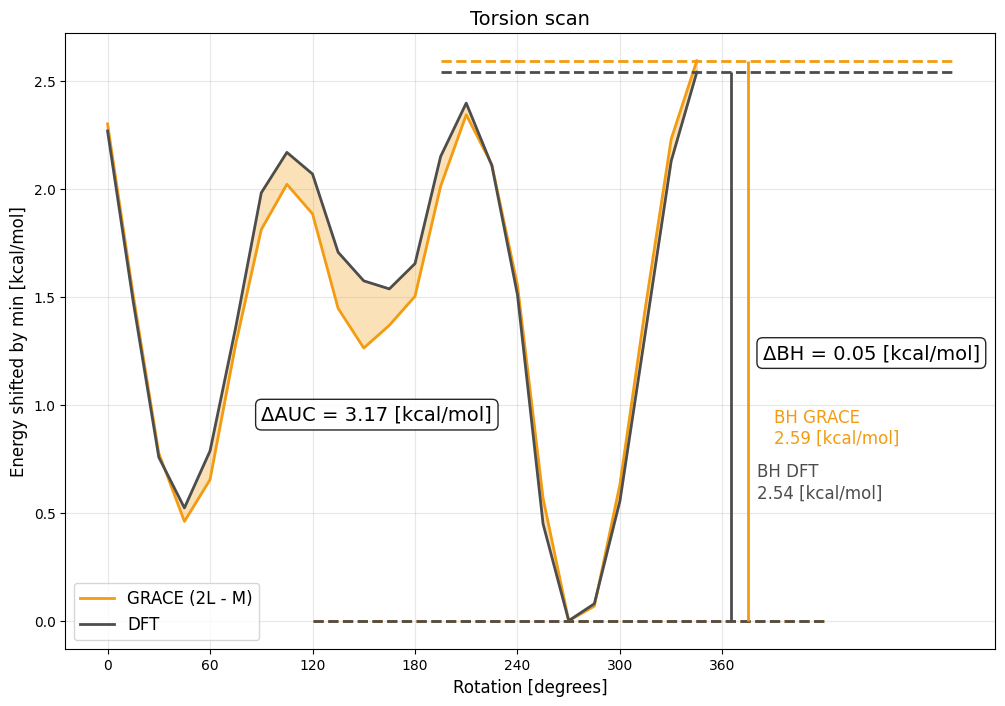

In [147]:
ev_to_kcal_mol = 23.0609

import h5py

single_torsion = pd.read_csv("torsion_scans/error_files/single_torsion.csv")

# colors from above
color_small = model_type_colors["GRACE_2L"]  
color_medium = model_type_colors["GRACE_2L"]
color_large = model_type_colors["GRACE_2L"] 
color_dft = "#4d4d4d"    
data_tnet = h5py.File("../data/TNet500-SPICE.hdf5", "r")
smiles = list(data_tnet.keys())[0]


torsion_small = np.asarray(single_torsion['small_2l']) - np.min(np.asarray(single_torsion['small_2l']))
torsion_small=torsion_small* ev_to_kcal_mol
torsion_med   = np.asarray(single_torsion['medium_2l']) - np.min(np.asarray(single_torsion['medium_2l']))
torsion_med=torsion_med* ev_to_kcal_mol
torsion_large = np.asarray(single_torsion['large_2l']) - np.min(np.asarray(single_torsion['large_2l']))
torsion_large=torsion_large* ev_to_kcal_mol
dft          = np.asarray(data_tnet[smiles]["dft total energy"]) * 27.211386245988
dft          = (dft - np.min(dft))
dft = dft * ev_to_kcal_mol

x = np.arange(len(dft))

area_small = np.trapz(np.abs(torsion_small - dft), x)
area_medium= np.trapz(np.abs(torsion_med - dft), x)
area_large = np.trapz(np.abs(torsion_large - dft), x)

x = np.arange(len(dft))*15

fig, ax1 = plt.subplots(1,1,figsize=(12, 8))



torsions = {
    "GRACE (2L - S)": torsion_small,
    "GRACE (2L - M)": torsion_med,
    "GRACE (2L - L)": torsion_large,
    "DFT": dft
}
colors = {
    "GRACE (2L - S)": color_small,
    "GRACE (2L - M)": color_medium,
    "GRACE (2L - L)": color_large,
    "DFT": color_dft
}

grace_model = "GRACE (2L - M)"
torsion_scan = torsions[grace_model]
color = colors[grace_model]

med_max = np.max(torsion_scan) 
dft_max = np.max(dft) 
med_min = np.min(torsion_scan) 
dft_min = np.min(dft)

BH_grace = med_max - med_min
BH_dft   = dft_max - dft_min
delta_BH = BH_grace - BH_dft

med_max_idx = np.argmax(torsion_scan)
med_min_idx = np.argmin(torsion_scan)
dft_max_idx = np.argmax(dft)
dft_min_idx = np.argmin(dft)

x_med_max = x[med_max_idx]
x_med_min = x[med_min_idx]
x_dft_max = x[dft_max_idx]
x_dft_min = x[dft_min_idx]
dx = 150

ax1.plot(x, torsion_scan, color=color, label=grace_model, linewidth=2)
ax1.plot(x, dft, color=color_dft, label="DFT", linewidth=2)
ax1.hlines(med_max, x_med_max - dx, x_med_max + dx,
           color=color, linestyle='--', linewidth=2,
        #    label=f"GRACE max: {med_max:.2f} eV"
           )

ax1.hlines(med_min, x_med_min - dx, x_med_min + dx,
           color=color, linestyle='--', linewidth=2,
        #    label=f"GRACE min: {med_min:.2f} eV"
           )

ax1.hlines(dft_max, x_dft_max - dx, x_dft_max + dx,
           color=color_dft, linestyle='--', linewidth=2,
        #    label=f"DFT max: {dft_max:.2f} eV"
           )

ax1.hlines(dft_min, x_dft_min - dx, x_dft_min + dx,
           color=color_dft, linestyle='--', linewidth=2,
        #    label=f"DFT min: {dft_min:.2f} eV"
           )
# GRACE barrier
ax1.vlines(x_med_max+30, med_min, med_max,
           color=color, linewidth=2)

# DFT barrier
ax1.vlines(x_dft_max+20, dft_min, dft_max,
           color=color_dft, linewidth=2)
# GRACE label
ax1.text(x_med_max+45, 
         med_min + BH_grace-1.7,
         f"BH GRACE\n{BH_grace:.2f} "+f"[kcal/mol]",
         color=color,
         fontsize=12,
         ha='left',
         va='center')
ax1.text(x_dft_max+35, 
         dft_min + BH_dft-1.9,
         f"BH DFT\n{BH_dft:.2f} "+f"[kcal/mol]",
         color=color_dft,
         fontsize=12,
         ha='left',
         va='center')
ax1.text(0.75, 0.48,
         f"ΔBH = {delta_BH:.2f} "+f"[kcal/mol]",
         transform=ax1.transAxes,
         fontsize=14,
         ha='left',
         va='center',
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   alpha=0.85,
                   edgecolor="black"))

ax1.text(0.335, 0.38,
         f"ΔAUC = {area_small:.2f} "+f"[kcal/mol]",
         transform=ax1.transAxes,
         fontsize=14,
         ha='center',
         va='center',
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   alpha=0.85,
                   edgecolor="black"))

ax1.fill_between(x, torsion_scan, dft, color=color, alpha=0.3)#, label=f"ΔAUC = {area_small:.2f} [eV]")
ax1.set_xticks(np.arange(0, 361, 60))
ax1.set_title("Torsion scan", fontsize=14)# \n GRACE 2L small vs DFT")
ax1.set_xlabel("Rotation [degrees]", fontsize=12)
ax1.set_ylabel("Energy shifted by min [kcal/mol]", fontsize=12)
ax1.legend(fontsize=12, loc='lower left')
ax1.grid(True, alpha=0.3)
plt.savefig("single_torsion_scan.pdf", bbox_inches="tight")